# PS3 — Problem 3: Quote Engine + Simulation

Simulate one trading day under the Avellaneda–Stoikov (2008) optimal market-making
policy and compare its terminal P&L distribution to a symmetric, inventory-ignoring
baseline.

**Mid-price dynamics (Week 3 lecture).** We simulate the mid as **arithmetic Brownian
motion** (ABM), \(dS_t = \sigma\, dW_t\), not geometric Brownian motion. The lecture
chooses ABM because, over a short market-making horizon, price changes are small and
roughly additive; it keeps the HJB linear in \(S\) and makes cash dynamics exact under
the CARA ansatz (see `weekly_presentations/week03_avellaneda_stoikov.tex`, Lecture 1).
In discrete time: \(S_{t+\Delta t} = S_t + \mathcal{N}(0, \sigma^2 \Delta t)\). ABM has
no positivity constraint, so a long path with \(S_0 = 100\) and \(\sigma = 2\) USD/√s can
cross below zero — that is expected for this model, not a bug.

**Problem parameters (fixed):**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `sigma` | 2.0 USD/√s | mid-price volatility |
| `kappa` | 1.5 | intensity decay in Λ(δ) = A·exp(−κδ) |
| `A` | 140 | fill intensity at δ = 0 in the problem statement (model-time units; see below) |

**Assumptions (not stated in the problem):**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `A` (simulation) | **0.07** fills/s | Rescaled from 140: the course reference (`as_engine.py`) uses `T=1`, `steps=2000` → `dt=0.0005`, so per-step rate is `140 × 0.0005 ≈ 0.07`. With our calendar `dt=1` s, `A` must be in fills/s to match that rate; `A=140` would saturate `p = min(1, A·e^{−κδ}·dt)` at 1 every tick. |
| `gamma` | **0.1** | course default; CARA risk aversion |
| `T` | 86,400 s | one trading day |
| `dt` | 1 s | matches σ units (USD/√s) |
| `S0` | 100 USD | arbitrary reference mid |
| `q_min`, `q_max` | ±10 | inventory limits (helper default) |
| `tau_risk` | 1.0 s | fixed AS risk horizon (decouples quote formulas from calendar length; matches `T=1` in the course reference while σ stays in USD/√s) |
| `N_SIMS` | 300 | Monte Carlo replications |

## 0 · Setup

In [1]:
import sys, pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers_futures.models.avellaneda_stoikov import ASParams, bid_ask, optimal_half_spread
from helpers_futures.models.simulation import simulate_as, simulate_symmetric, pnl_stats

OUT_DIR = ROOT / "output"
FIG_DIR = ROOT / "figures"
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})
print("Environment ready.")

Environment ready.


## 1 · Model Parameters

In [2]:
DT = 1.0
T = 86_400.0          # one trading day in seconds
S0 = 100.0
N_SIMS = 1000
BASE_SEED = 99

params = ASParams(
    gamma=0.1,
    sigma=2.0,
    kappa=1.5,
    A=0.07,
    T=T,
    tau_risk=1.0,
)

N_STEPS = int(T / DT)
half_spread_t0 = optimal_half_spread(0.0, params)

print(f"Horizon: {T:.0f} s  ({N_STEPS:,} steps at dt={DT:.0f} s)")
print(f"σ={params.sigma}, γ={params.gamma}, κ={params.kappa}, A={params.A}")
print(f"Optimal half-spread at t=0: {half_spread_t0:.4f} USD")
print()
print(f"{'q':>4}  {'bid':>10}  {'ask':>10}  {'spread':>10}")
for q in [-5, 0, 5]:
    bid, ask = bid_ask(S0, q, 0.0, params)
    print(f"{q:4d}  {bid:10.4f}  {ask:10.4f}  {ask - bid:10.4f}")

Horizon: 86400 s  (86,400 steps at dt=1 s)
σ=2.0, γ=0.1, κ=1.5, A=0.07
Optimal half-spread at t=0: 0.8454 USD

   q         bid         ask      spread
  -5    101.1546    102.8454      1.6908
   0     99.1546    100.8454      1.6908
   5     97.1546     98.8454      1.6908


## 2 · Synthetic Price Path

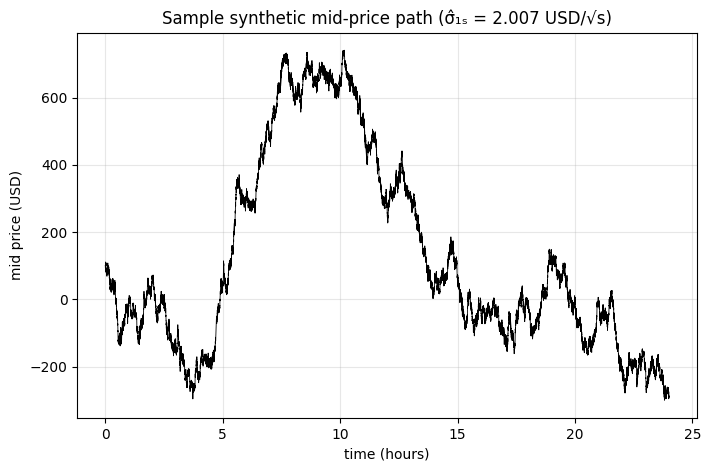

Path length: 86,400  (T = 86400 s)
Start / end: 100.61 → -275.95 USD
1-step vol estimate: 2.0069  (target σ = 2.0)


In [3]:
def generate_price_path(
    S0: float,
    sigma: float,
    T: float,
    dt: float,
    seed: int,
) -> np.ndarray:
    """Arithmetic Brownian motion mid-price path."""
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    increments = rng.normal(0.0, sigma * np.sqrt(dt), size=n_steps)
    return S0 + np.cumsum(increments)


demo_path = generate_price_path(S0, params.sigma, T, DT, seed=42)
demo_vol = float(np.std(np.diff(demo_path)))

fig, ax = plt.subplots()
hours = np.arange(len(demo_path)) / 3600.0
ax.plot(hours, demo_path, lw=0.6, color="k")
ax.set_xlabel("time (hours)")
ax.set_ylabel("mid price (USD)")
ax.set_title(f"Sample synthetic mid-price path (σ̂₁ₛ = {demo_vol:.3f} USD/√s)")
fig.savefig(FIG_DIR / "ps3_p3_sample_price_path.png", bbox_inches="tight")
plt.show()

print(f"Path length: {len(demo_path):,}  (T = {len(demo_path) * DT:.0f} s)")
print(f"Start / end: {demo_path[0]:.2f} → {demo_path[-1]:.2f} USD")
print(f"1-step vol estimate: {demo_vol:.4f}  (target σ = {params.sigma})")

## 3 · Monte Carlo Simulation

Each replication uses the **same seed** for both strategies so they face the
identical price path and fill randomness; divergence comes only from quoting policy.

In [4]:
def run_monte_carlo(
    params: ASParams,
    n_sims: int,
    S0: float,
    dt: float,
    base_seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    opt_pnls = np.empty(n_sims)
    sym_pnls = np.empty(n_sims)
    for i in range(n_sims):
        seed = base_seed + i
        price = generate_price_path(S0, params.sigma, params.T, dt, seed)
        state_opt = simulate_as(params, price, dt=dt, seed=seed)
        state_sym = simulate_symmetric(params, price, dt=dt, seed=seed)
        opt_pnls[i] = state_opt.pnl[-1]
        sym_pnls[i] = state_sym.pnl[-1]
    return opt_pnls, sym_pnls


opt_pnls, sym_pnls = run_monte_carlo(params, N_SIMS, S0, DT, BASE_SEED)

summary = pd.DataFrame({
    "strategy": ["optimal (A-S)", "symmetric baseline"],
    "mean_pnl": [opt_pnls.mean(), sym_pnls.mean()],
    "std_pnl": [opt_pnls.std(), sym_pnls.std()],
    "p05": [np.percentile(opt_pnls, 5), np.percentile(sym_pnls, 5)],
    "p50": [np.median(opt_pnls), np.median(sym_pnls)],
    "p95": [np.percentile(opt_pnls, 95), np.percentile(sym_pnls, 95)],
})
display(summary.round(2))

,strategy,mean_pnl,std_pnl,p05,p50,p95
0,optimal (A-S),2555.13,538.95,1662.77,2568.17,3453.62
1,symmetric baseline,2470.40,3443.61,-3005.64,2300.31,8267.30


## 4 · P&L Distribution

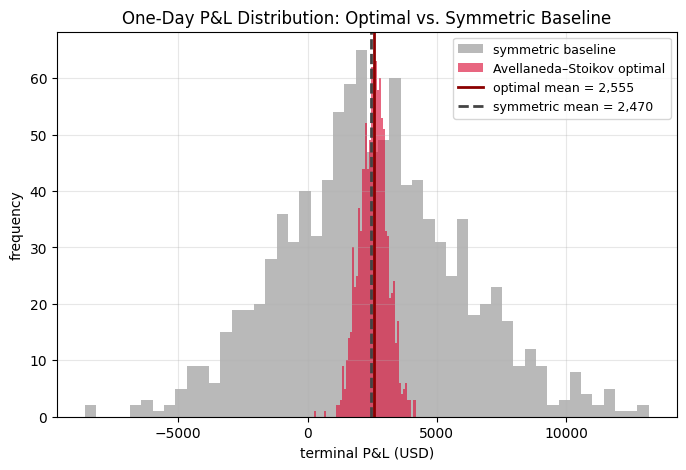

Saved /Users/stark/Desktop/Projects/ncsu_finmath_summer_2026/weekly_assignments/week3/output/ps3_p3_pnl_distribution.csv
Variance ratio (sym/opt): 40.83x


In [5]:
fig, ax = plt.subplots()
bins = 50
ax.hist(sym_pnls, bins=bins, alpha=0.55, color="gray", label="symmetric baseline")
ax.hist(opt_pnls, bins=bins, alpha=0.65, color="crimson", label="Avellaneda–Stoikov optimal")
ax.axvline(opt_pnls.mean(), color="darkred", lw=2, label=f"optimal mean = {opt_pnls.mean():,.0f}")
ax.axvline(sym_pnls.mean(), color="#444", lw=2, ls="--", label=f"symmetric mean = {sym_pnls.mean():,.0f}")
ax.set_xlabel("terminal P&L (USD)")
ax.set_ylabel("frequency")
ax.set_title("One-Day P&L Distribution: Optimal vs. Symmetric Baseline")
ax.legend(fontsize=9)
fig.savefig(FIG_DIR / "ps3_p3_pnl_distribution.png", bbox_inches="tight")
plt.show()

pnl_df = pd.DataFrame({
    "run": np.arange(N_SIMS),
    "pnl_optimal": opt_pnls,
    "pnl_symmetric": sym_pnls,
})
csv_path = OUT_DIR / "ps3_p3_pnl_distribution.csv"
pnl_df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")
print(f"Variance ratio (sym/opt): {(sym_pnls.std() / opt_pnls.std())**2:.2f}x")

## 5 · Single-Day Diagnostics

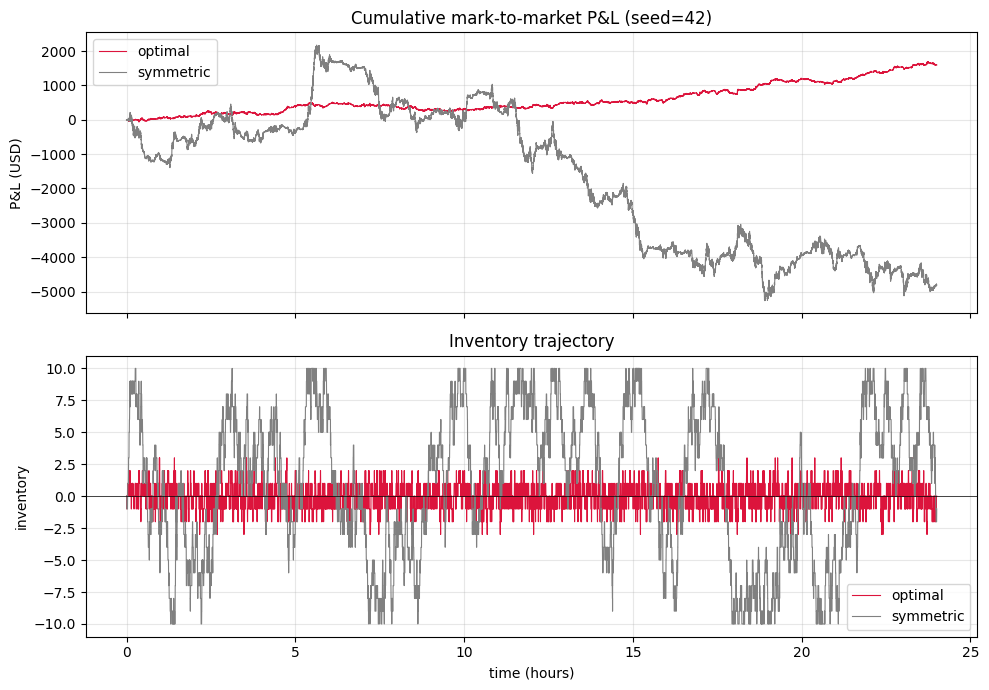

,final_pnl,mean_step_return,std_step_return,sharpe,max_drawdown,mean_inventory,std_inventory
optimal,1596.1443,0.0185,1.8476,2.9390,292.9545,-0.0372,0.914
symmetric,-4815.2119,-0.0557,11.5194,-1.4221,7438.6273,0.9915,5.636


In [6]:
DIAG_SEED = 42
price_diag = generate_price_path(S0, params.sigma, T, DT, DIAG_SEED)
state_as = simulate_as(params, price_diag, dt=DT, seed=DIAG_SEED)
state_sym = simulate_symmetric(params, price_diag, dt=DT, seed=DIAG_SEED)

time_h = np.arange(len(price_diag)) / 3600.0
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(time_h, state_as.pnl, color="crimson", lw=0.8, label="optimal")
axes[0].plot(time_h, state_sym.pnl, color="gray", lw=0.8, label="symmetric")
axes[0].set_ylabel("P&L (USD)")
axes[0].set_title("Cumulative mark-to-market P&L (seed=42)")
axes[0].legend()

axes[1].plot(time_h, state_as.inv_series, color="crimson", lw=0.8, label="optimal")
axes[1].plot(time_h, state_sym.inv_series, color="gray", lw=0.8, label="symmetric")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("time (hours)")
axes[1].set_ylabel("inventory")
axes[1].set_title("Inventory trajectory")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "ps3_p3_single_day_diagnostics.png", bbox_inches="tight")
plt.show()

stats_as = pnl_stats(state_as)
stats_sym = pnl_stats(state_sym)
diag = pd.DataFrame({"optimal": stats_as, "symmetric": stats_sym}).T
display(diag.round(4))

### Interpretation

1. **Inventory mean-reversion (optimal).** The A–S reservation price shifts quotes
   against inventory: when long, bid/ask move down to encourage selling. Inventory
   oscillates near zero. The symmetric baseline quotes at mid regardless of `q`, so
   inventory drifts and can accumulate.

2. **Lower P&L variance (optimal).** By controlling inventory risk, the optimal policy
   produces a tighter terminal P&L distribution. The baseline captures similar spread
   P&L on average but suffers larger swings from unhedged inventory exposure.

3. **Positive expected P&L.** Both policies earn the bid–ask spread from fills
   (simulation uses `A = 0.07` fills/s, rescaled from the problem's `A = 140` to
   match the per-step arrival rate under `dt = 1` s). The optimal policy trades some
   spread width for inventory control via the reservation-price skew.